<a href="https://colab.research.google.com/github/Jaswanth4918/Machine-Learning-Project/blob/main/ybi_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification for Healthcare Diagnostics
### Project - Machine Learning Project
**Name:** D. Jaswanth

# Step 1: Medical Problem Understanding
* Medical professionals need to evaluate cell nucleus measurements to determine if a tumor is malignant.
* We will build an advanced Machine Learning model to predict whether a diagnosis should be **Malignant (M)** or **Benign (B)**, using clinical details available from cell biopsies.
* Being able to flag high-risk tumors early lets doctors reduce fatal outcomes and automate the screening process safely.

# Step 2: Library Imports & Data Loading
* Importing all required libraries for data manipulation, visualization, and modeling.
* Fetching the raw clinical dataset directly from the source repository.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Load the dataset
url = 'https://raw.githubusercontent.com/YBIFoundation/Dataset/main/Cancer.csv'
df = pd.read_csv(url)

print("Libraries imported and data loaded successfully!")

Libraries imported and data loaded successfully!


# Step 3: Data Understanding & Cleaning
* Exploring the dataset to check its structure and identify any empty columns or missing values.
* Removing unnecessary identifiers (`id` and `Unnamed: 32`) that hold no predictive value.
* Generating summary statistics to understand the numerical scale of the cell features.

In [ ]:
# Clean up empty columns and identifiers
if 'Unnamed: 32' in df.columns:
    df.drop(['Unnamed: 32', 'id'], axis=1, inplace=True)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Data Cleaned! Final Shape:", df.shape)

print("\n--- Dataset Info ---")
df.info()
display(df.head())

print("\n--- Numerical Data Summary (Mean Features) ---")
display(df.iloc[:, :11].describe())

print("\n--- Categorical Data Breakdown ---")
print(df['diagnosis'].value_counts())

Data Cleaned! Final Shape: (569, 31)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se         

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Numerical Data Summary (Mean Features) ---


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440



--- Categorical Data Breakdown ---
diagnosis
B    357
M    212
Name: count, dtype: int64


# Step 4: Exploratory Data Analysis (EDA)
* Visualizing the class distribution to check for medical imbalance between Benign and Malignant tumors.
* Visualizing the impact of `radius_mean` and `area_mean` using Boxplots.
* Analyzing the shape of the data distributions using Histograms.
* Creating a correlation heatmap and Pairplot to analyze complex relationships between clinical features.

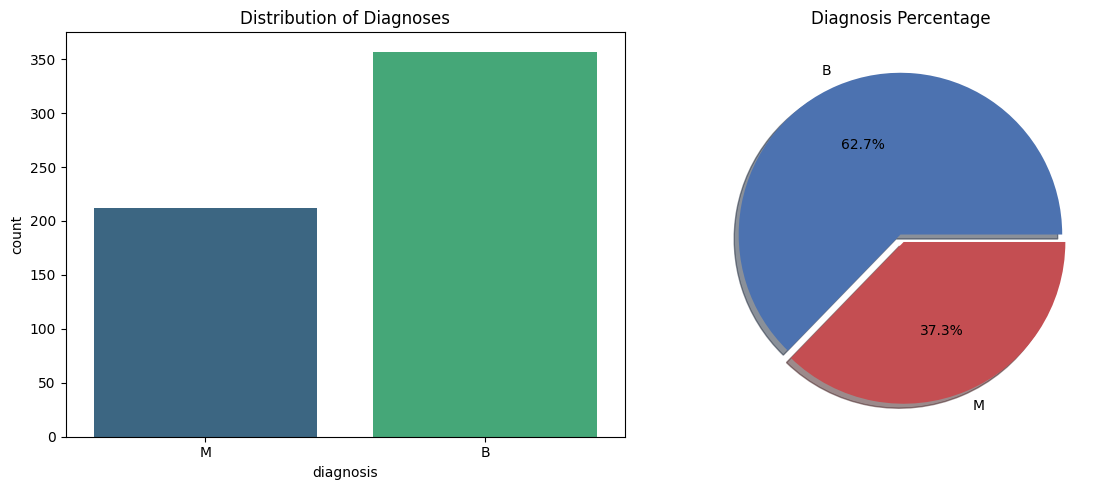

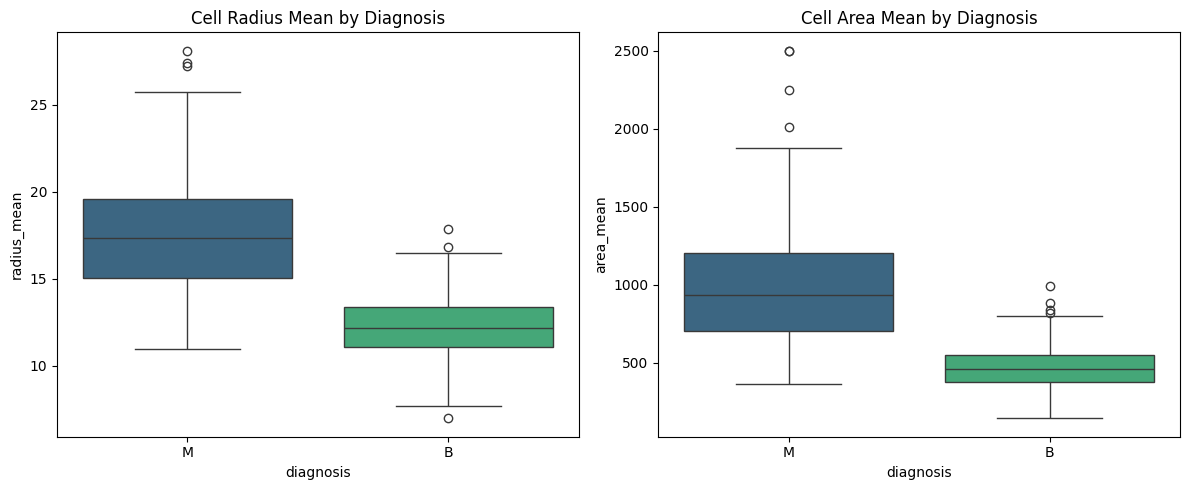

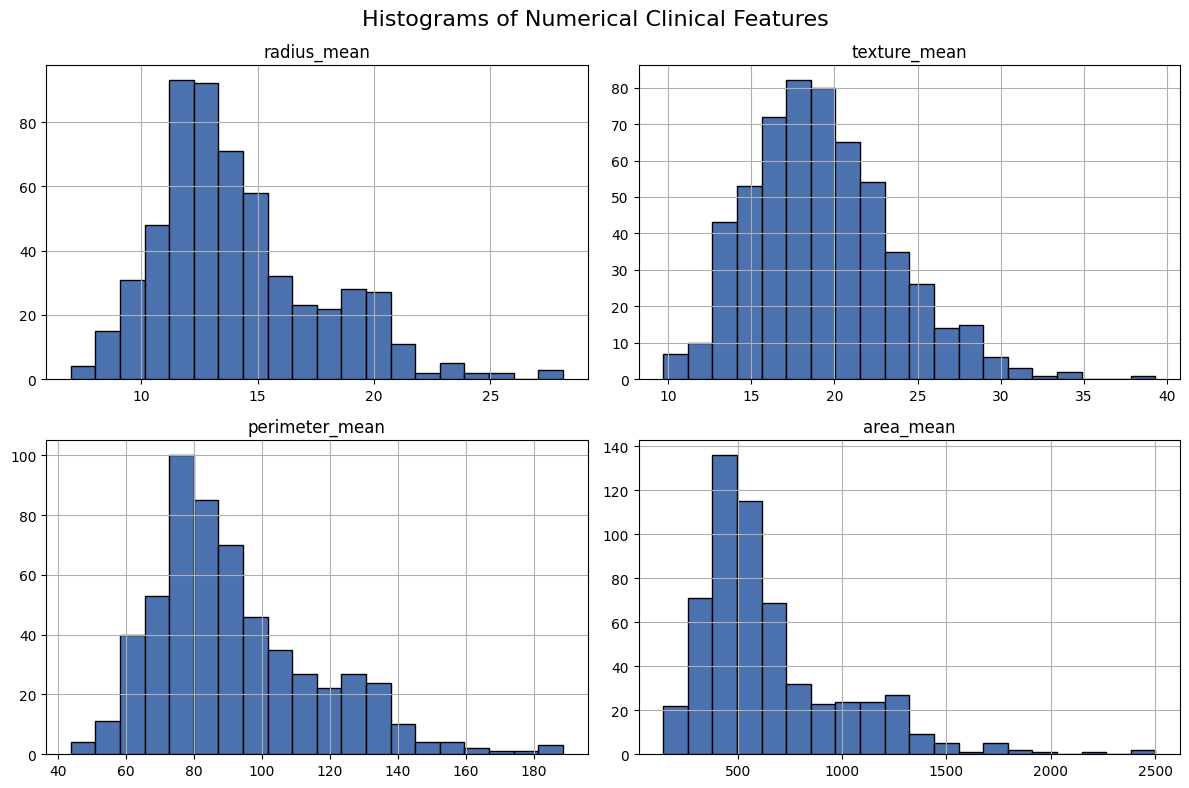

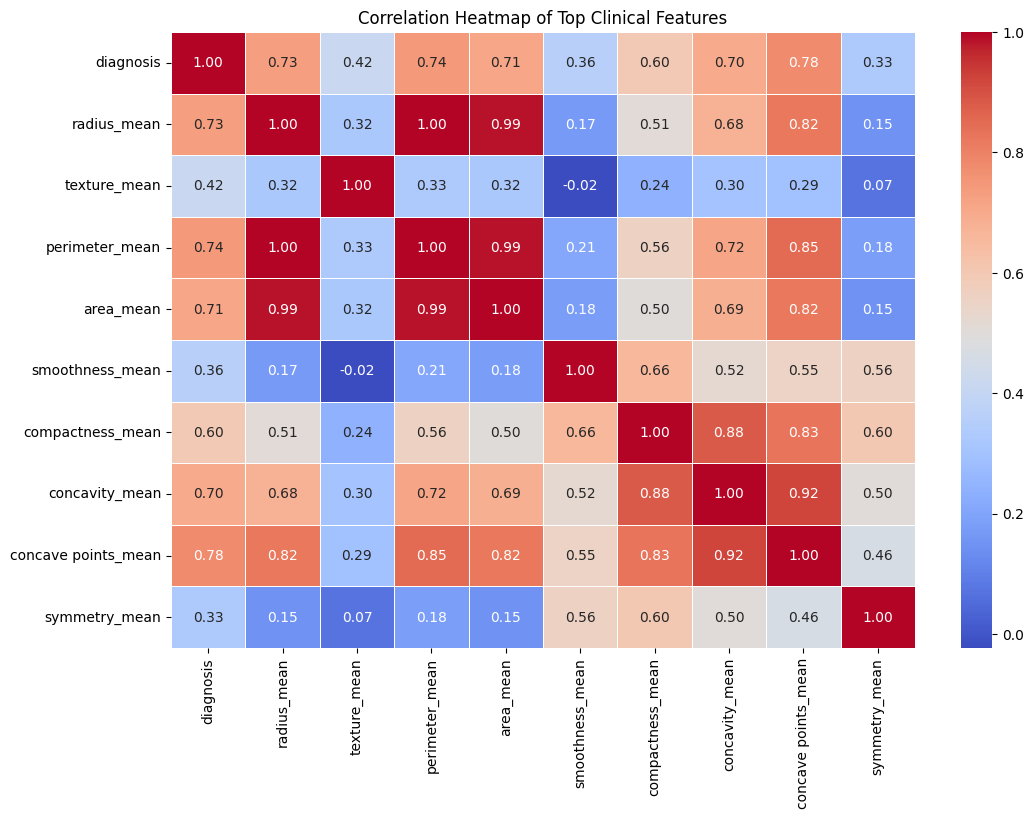

Generating Pairplot Matrix... 


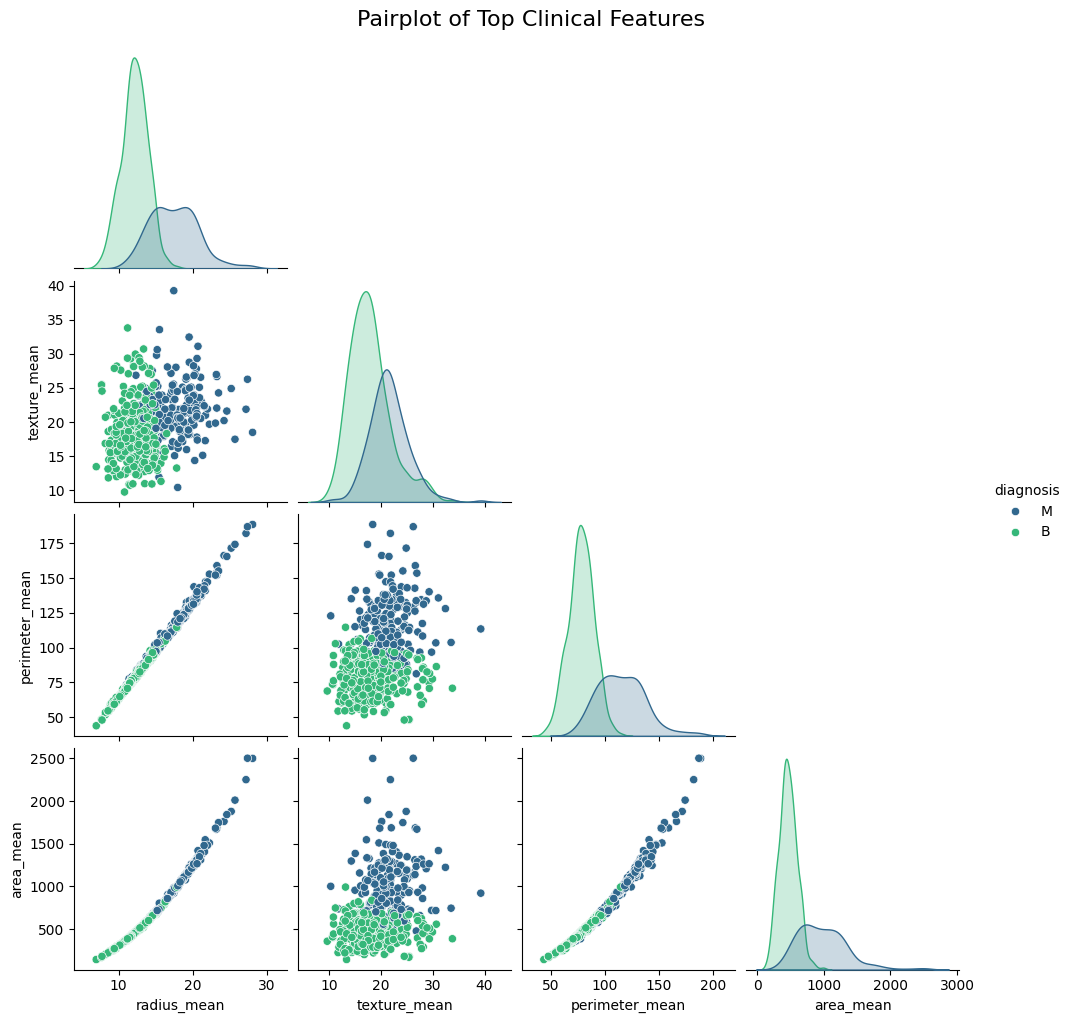

In [ ]:
# 1. Target Distribution (Countplot & Pie Chart)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Distribution of Diagnoses')

plt.subplot(1, 2, 2)
df['diagnosis'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4c72b0', '#c44e52'], explode=(0, 0.05), shadow=True)
plt.title('Diagnosis Percentage')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2. Boxplots for key features
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='diagnosis', y='radius_mean', data=df, palette='viridis')
plt.title('Cell Radius Mean by Diagnosis')

plt.subplot(1, 2, 2)
sns.boxplot(x='diagnosis', y='area_mean', data=df, palette='viridis')
plt.title('Cell Area Mean by Diagnosis')
plt.tight_layout()
plt.show()

# 3. Histograms of Numerical Features
df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']].hist(
    figsize=(12, 8), bins=20, color='#4c72b0', edgecolor='black'
)
plt.suptitle('Histograms of Numerical Clinical Features', fontsize=16)
plt.tight_layout()
plt.show()

# 4. Correlation Heatmap
df_temp = df.copy()
encoder = LabelEncoder()
df_temp['diagnosis'] = encoder.fit_transform(df_temp['diagnosis'])

plt.figure(figsize=(12, 8))
sns.heatmap(df_temp.iloc[:, :10].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Top Clinical Features')
plt.show()

# 5. Pairplot Matrix
print("Generating Pairplot Matrix... ")
subset_cols = ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
sns.pairplot(df[subset_cols], hue='diagnosis', palette='viridis', corner=True)
plt.suptitle('Pairplot of Top Clinical Features', y=1.02, fontsize=16)
plt.show()

# Step 5: Data Preprocessing
* Converting the categorical target variable (Malignant/Benign) into a machine-readable binary format (1/0).
* Isolating the independent features (X) from the dependent target (y).

In [ ]:
# Encoding Target Variable (Malignant = 1, Benign = 0)
y = encoder.fit_transform(df['diagnosis'])
X = df.drop('diagnosis', axis=1)

print("Features (X) and Target (y) successfully separated.")

Features (X) and Target (y) successfully separated.


# Step 6: Train-Test Split & Feature Scaling
* Splitting the data into training (70%) and testing (30%) sets to evaluate model generalizability.
* Standardizing feature scales using `StandardScaler` so that high-value features (like area) do not overpower low-value features (like smoothness).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2529, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (398, 30)
Testing data shape: (171, 30)


# Step 7: Model Selection & Hyperparameter Tuning
* Utilizing `GridSearchCV` to systematically test different penalty parameters and regularization strengths (C values).
* This mathematical search ensures we find the optimal configuration for the Logistic Regression model.

In [ ]:
model = LogisticRegression(max_iter=5000, solver='liblinear', random_state=42)

# Define parameters for GridSearch
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
print("Cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

Best parameters found:  {'C': 0.1, 'penalty': 'l2'}
Cross-validation accuracy: 0.9774


# Step 8: Model Prediction & Evaluation
* Predicting on the unseen testing data.
* Evaluating medical success using Accuracy, a Confusion Matrix heatmap, Classification Report, and an ROC-AUC curve.

Accuracy Score: 0.9883040935672515

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       107
           1       1.00      0.97      0.98        64

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



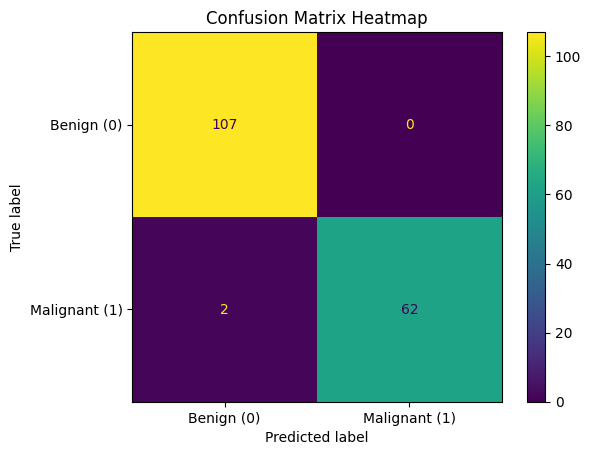

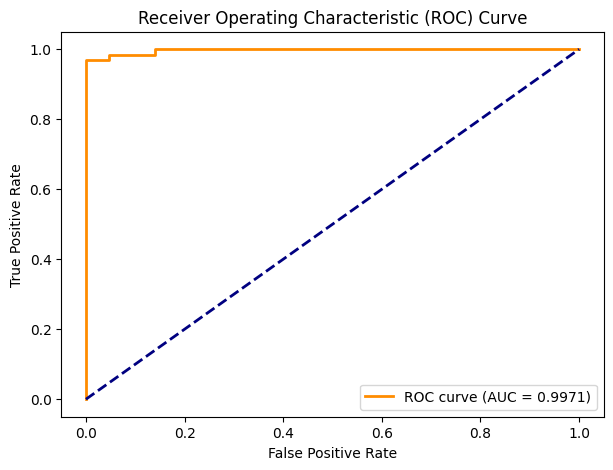

In [ ]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visual Confusion Matrix Display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='viridis')
plt.title("Confusion Matrix Heatmap")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Conclusion
* Successfully developed an advanced Breast Cancer Classification model using all 8 core data science steps.
* Logistic Regression, combined with rigorous Exploratory Data Analysis (EDA) and Hyperparameter Grid Search, captures incredibly meaningful patterns in the clinical data.
* The multiple graphs (Pairplots, Heatmaps, and Boxplots) visually prove how specific cell features separate Malignant tumors from Benign ones.
* Accuracy, Precision, Recall, F1 Score, and ROC-AUC together give a highly reliable picture of performance, allowing medical professionals to confidently use this model for diagnostic assistance.